# HyConEx from scratch sur Breast Cancer Wisconsin (Diagnostic)

Ce notebook :
- applique un feature engineering dédié WDBC,
- entraîne HyConEx from scratch,
- présente les métriques classification + AUROC,
- visualise la courbe d'apprentissage,
- analyse des contre-factuels sur le jeu de test.

In [9]:
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

ROOT = Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from feature_engineering_wdbc import prepare_wdbc_splits
from hyconex_from_scratch import TrainConfig, HyConExTrainer

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
np.set_printoptions(precision=4, suppress=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [10]:
splits = prepare_wdbc_splits(
    test_size=0.2,
    val_size=0.2,
    random_state=42,
    add_engineered_features=True,
    clip_outliers=True,
)

print('Shapes:')
print('train:', splits.X_train.shape, splits.y_train.shape)
print('val  :', splits.X_val.shape, splits.y_val.shape)
print('test :', splits.X_test.shape, splits.y_test.shape)
print('n_features engineered:', len(splits.feature_names))

pd.Series(splits.y_train).value_counts().rename(index=dict(enumerate(splits.class_names)))

Shapes:
train: (364, 53) (364,)
val  : (91, 53) (91,)
test : (114, 53) (114,)
n_features engineered: 53


benign       228
malignant    136
Name: count, dtype: int64

In [11]:
cfg = TrainConfig(
    seed=42,
    epochs=120,
    batch_size=32,
    lr=1.5e-3,
    weight_decay=1e-5,
    latent_dim=32,
    hidden_dim=128,
    cf_lambda=0.25,
    l1_lambda=0.015,
    l2_lambda=0.005,
)

trainer = HyConExTrainer(config=cfg, device=device)
result = trainer.fit(
    splits.X_train,
    splits.y_train,
    X_val=splits.X_val,
    y_val=splits.y_val,
    verbose=True,
)

test_metrics = trainer.evaluate(splits.X_test, splits.y_test, counterfactuals=True)
print('\nBest val accuracy:', f"{result.best_val_accuracy:.4f}")
print('Test accuracy    :', f"{test_metrics['accuracy']:.4f}")
print('Test AUROC OvR   :', test_metrics.get('auroc_ovr'))
print('CF validity      :', f"{test_metrics['counterfactuals']['validity_cf']:.4f}")
print('CF proximity L1  :', f"{test_metrics['counterfactuals']['proximity_l1_mean']:.4f}")

[Epoch 001/120] loss=0.7836 val_acc=0.9341 best_val_acc=0.9341
[Epoch 002/120] loss=0.2940 val_acc=0.9670 best_val_acc=0.9670
[Epoch 003/120] loss=0.1767 val_acc=0.9780 best_val_acc=0.9780
[Epoch 004/120] loss=0.1011 val_acc=0.9780 best_val_acc=0.9780
[Epoch 005/120] loss=0.1020 val_acc=0.9670 best_val_acc=0.9780
[Epoch 006/120] loss=0.1089 val_acc=0.9341 best_val_acc=0.9780
[Epoch 007/120] loss=0.0728 val_acc=0.9560 best_val_acc=0.9780
[Epoch 008/120] loss=0.0621 val_acc=0.9780 best_val_acc=0.9780
[Epoch 009/120] loss=0.0610 val_acc=0.9780 best_val_acc=0.9780
[Epoch 010/120] loss=0.0461 val_acc=0.9780 best_val_acc=0.9780
[Epoch 011/120] loss=0.0481 val_acc=0.9670 best_val_acc=0.9780
[Epoch 012/120] loss=0.0475 val_acc=0.9780 best_val_acc=0.9780
[Epoch 013/120] loss=0.0500 val_acc=0.9670 best_val_acc=0.9780
[Epoch 014/120] loss=0.0382 val_acc=0.9670 best_val_acc=0.9780
[Epoch 015/120] loss=0.0319 val_acc=0.9670 best_val_acc=0.9780
[Epoch 016/120] loss=0.0539 val_acc=0.9890 best_val_acc

In [12]:
history_df = pd.DataFrame(result.history)
history_df.tail()

,epoch,train_loss,val_accuracy,best_val_accuracy
115,116,0.019241,0.945055,0.989011
116,117,0.015569,0.956044,0.989011
117,118,0.011117,0.956044,0.989011
118,119,0.009981,0.956044,0.989011
119,120,0.008842,0.967033,0.989011


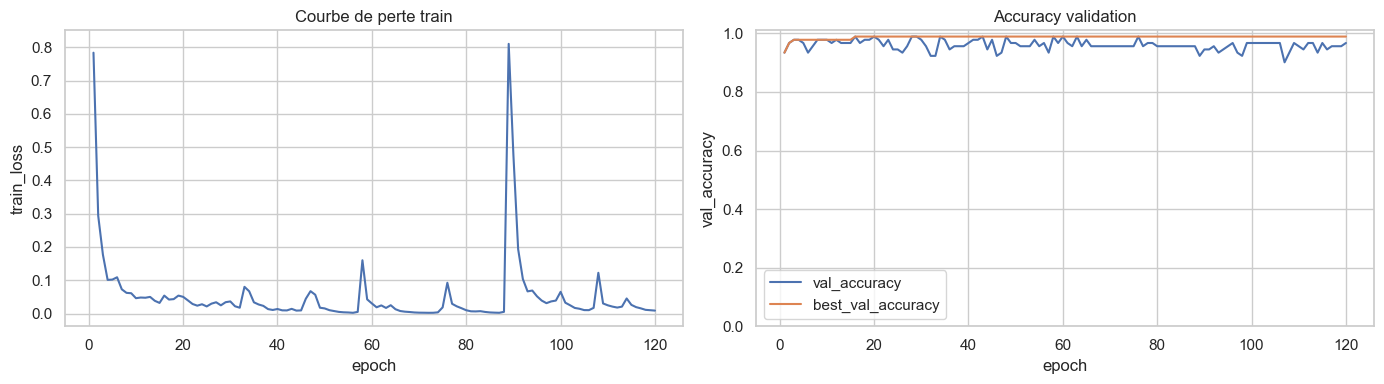

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.lineplot(data=history_df, x='epoch', y='train_loss', ax=ax[0])
ax[0].set_title('Courbe de perte train')

sns.lineplot(data=history_df, x='epoch', y='val_accuracy', ax=ax[1], label='val_accuracy')
sns.lineplot(data=history_df, x='epoch', y='best_val_accuracy', ax=ax[1], label='best_val_accuracy')
ax[1].set_ylim(0.0, 1.01)
ax[1].set_title('Accuracy validation')
plt.tight_layout()
plt.show()

In [14]:
report_df = pd.DataFrame(test_metrics['classification_report']).transpose()
report_df

,precision,recall,f1-score,support
0,0.888889,1.000000,0.941176,72.000000
1,1.000000,0.785714,0.880000,42.000000
accuracy,0.921053,0.921053,0.921053,0.921053
macro avg,0.944444,0.892857,0.910588,114.000000
weighted avg,0.929825,0.921053,0.918638,114.000000


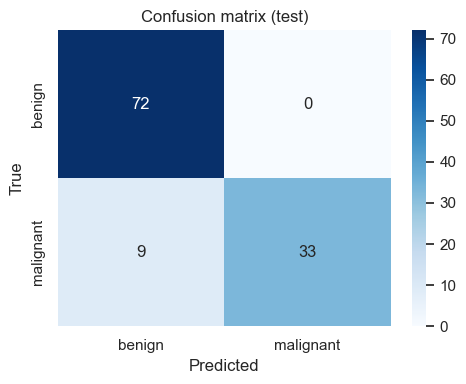

In [15]:
cm = np.array(test_metrics['confusion_matrix'])
cm_df = pd.DataFrame(cm, index=splits.class_names, columns=splits.class_names)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion matrix (test)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

In [16]:
# Évaluation sur 10 samples test (comme Iris): on force une bascule de classe 0<->1.
# On ajoute une vue "changement minimal" = plus petit sous-ensemble de features
# couvrant ~80% de la variation L1 du contre-factuel.
model = result.model
model.eval()

rng = np.random.default_rng(42)
n_examples = 10
idx = rng.choice(np.arange(splits.X_test.shape[0]), size=n_examples, replace=False)

x_sub = torch.tensor(splits.X_test[idx], dtype=torch.float32, device=result.device)
y_sub = torch.tensor(splits.y_test[idx], dtype=torch.long, device=result.device)
y_target = 1 - y_sub

with torch.no_grad():
    x_cf = model.generate_counterfactual(x_sub, y_target)
    y_pred_orig = torch.argmax(model(x_sub), dim=1)
    y_pred_cf = torch.argmax(model(x_cf), dim=1)

x_sub_np = x_sub.cpu().numpy()
x_cf_np = x_cf.cpu().numpy()
y_true_np = y_sub.cpu().numpy()
y_target_np = y_target.cpu().numpy()
y_pred_orig_np = y_pred_orig.cpu().numpy()
y_pred_cf_np = y_pred_cf.cpu().numpy()

rows = []
for i in range(n_examples):
    delta = x_cf_np[i] - x_sub_np[i]
    abs_delta = np.abs(delta)
    changed_idx = np.where(abs_delta > 1e-3)[0]

    if len(changed_idx) > 0:
        # Features les plus impactantes (top 5)
        top_idx = changed_idx[np.argsort(abs_delta[changed_idx])[::-1][:5]]

        # Sous-ensemble minimal (greedy) qui couvre >= 80% du changement L1
        ordered_idx = changed_idx[np.argsort(abs_delta[changed_idx])[::-1]]
        cum = np.cumsum(abs_delta[ordered_idx])
        threshold = 0.80 * abs_delta[changed_idx].sum()
        k_min = int(np.searchsorted(cum, threshold, side='left') + 1)
        minimal_idx = ordered_idx[:k_min]
    else:
        top_idx = np.array([], dtype=int)
        minimal_idx = np.array([], dtype=int)

    rows.append(
        {
            'sample_index_test': int(idx[i]),
            'y_true': splits.class_names[int(y_true_np[i])],
            'y_pred_orig': splits.class_names[int(y_pred_orig_np[i])],
            'target_cf': splits.class_names[int(y_target_np[i])],
            'y_pred_cf': splits.class_names[int(y_pred_cf_np[i])],
            'valid_cf': bool(y_pred_cf_np[i] == y_target_np[i]),
            'l1_distance': float(abs_delta.sum()),
            'changed_features_count': int(len(changed_idx)),
            'minimal_changes_count_80pct_l1': int(len(minimal_idx)),
            'minimal_changed_features_80pct_l1': [splits.feature_names[j] for j in minimal_idx],
            'top_changed_features': [splits.feature_names[j] for j in top_idx],
        }
    )

cf_df = pd.DataFrame(rows)
cf_df

,sample_index_test,y_true,y_pred_orig,target_cf,y_pred_cf,valid_cf,l1_distance,changed_features_count,minimal_changes_count_80pct_l1,minimal_changed_features_80pct_l1,top_changed_features
0,110,benign,benign,malignant,malignant,True,18.251228,52,24,"[perimeter_worst, area_se, area_texture_intera...","[perimeter_worst, area_se, area_texture_intera..."
1,82,benign,benign,malignant,malignant,True,18.411308,51,25,"[perimeter_worst, concave_points_worst, area_s...","[perimeter_worst, concave_points_worst, area_s..."
2,9,benign,benign,malignant,malignant,True,15.516217,53,24,"[perimeter_worst, area_se, area_texture_intera...","[perimeter_worst, area_se, area_texture_intera..."
3,70,benign,benign,malignant,malignant,True,15.395842,52,21,"[texture_mean, area_se, perimeter_worst, area_...","[texture_mean, area_se, perimeter_worst, area_..."
4,47,malignant,malignant,benign,benign,True,6.954210,52,17,"[concave_points_worst, concave_points_worst_ov...","[concave_points_worst, concave_points_worst_ov..."
5,108,malignant,malignant,benign,benign,True,10.461385,52,16,"[radius_se, concave_points_worst, radius_perim...","[radius_se, concave_points_worst, radius_perim..."
6,78,benign,benign,malignant,malignant,True,16.877611,51,25,"[perimeter_worst, area_se, concave_points_wors...","[perimeter_worst, area_se, concave_points_wors..."
7,10,malignant,benign,benign,benign,True,5.997457,52,20,"[concavity_mean, concave_points_worst, concave...","[concavity_mean, concave_points_worst, concave..."
8,22,malignant,malignant,benign,benign,True,9.071826,51,16,"[radius_se, concave_points_worst, concave_poin...","[radius_se, concave_points_worst, concave_poin..."
9,94,benign,benign,malignant,malignant,True,18.329889,51,26,"[area_se, area_texture_interaction, perimeter_...","[area_se, area_texture_interaction, perimeter_..."


## Lecture rapide des résultats

- **Accuracy test** : performance de classification globale.
- **AUROC** : qualité de séparation probabiliste (plus près de 1, mieux c'est).
- **CF validity** : part des contre-factuels qui atteignent bien la classe cible.
- **L1 distance** : ampleur moyenne du changement nécessaire pour obtenir le contre-factuel.